# Analiza finančnih podatkov podjetij

Analizirali bomo podatke 500 največjih podjetji na svetu glede na tržno kapitalizacijo (market capitalization).
Tržna kapitalizacija predstavlja skupno tržno vrednost vseh izdanih delnic podjetja in je eden ključnih pokazateljev velikosti ter vpliva posameznega podjetja na globalnem trgu.

Glavni cilj analize je ugotoviti, kako se svetovni kapital porazdeljuje med posamezne države in podjetja ter preučiti povezavo med velikostjo podjetij in ali manjša skupina podjetij drži večino trga, kakšna je povezava med tržno kapitalizacijo in dnevnimi spremembami cen delnic ter katera podjetja izstopajo kot ekstremni osamelci (Z-score).

Podatke za analizo sem pridobila iz spletne strani https://companiesmarketcap.com/, na dan 24.9.2026.

Pythonove knjižnjice, ki sem jh uporabila za analizo podatkov in risanje grafov.

In [10]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

MAPA_GRAFOV = "grafi"

## 1. Geografska porazdelitev podjetij
Zanima nas tržna vrednost (market capitalization) vseh podjetji ene države in katera podjetja iz te države so se uvrstila med top 500 podjetji na svetu.

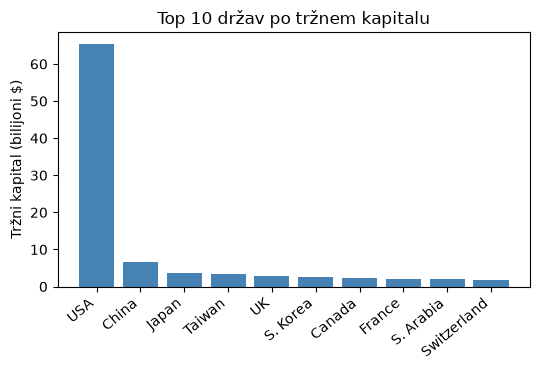

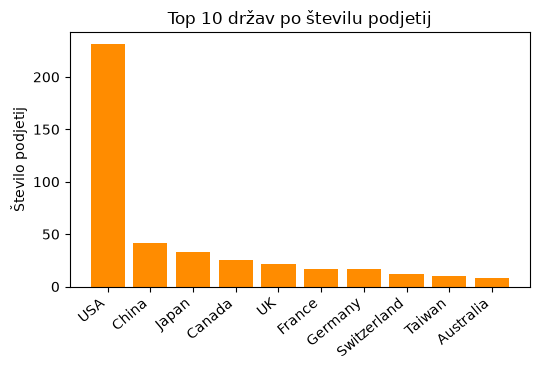

In [ ]:
top_n=10

kapital_po_drzavah = df.groupby("Drzava")["Market_Cap_USD"].sum().sort_values(ascending=False)
stevilo_po_drzavah = df.groupby("Drzava")["Market_Cap_USD"].count().sort_values(ascending=False)

top_kapital = kapital_po_drzavah.head(top_n) # izbere le prvih 10
top_stevilo = stevilo_po_drzavah.head(top_n) # izbere le prvih 10. top_stevilo ni pythonov klasicen slovar ampak pandasova struktura series, ki deluje zelo podobno kot slovar

# graf je bil generiran s pomočjo umetne inteligence
plt.figure(figsize=(5.5, 3.8)) # figure ustvari nov prostor za sliko, figsize določa dimenzijo slike v inčih
plt.bar(top_kapital.index, top_kapital.values / 1e12, color="steelblue") # index določa x os, values pa y os
plt.ylabel("Tržni kapital (bilijoni $)") # besedilo ob vertikalni (Y) osi
plt.title(f"Top {top_n} držav po tržnem kapitalu") # glavni naslov grafa
plt.xticks(rotation=40, ha="right") # napisana imena držav na spodnji (X) osi
plt.tight_layout() # poskrbi da so vsi napisi vidni znotraj okvira slike
plt.show() # zapre graf. če tega ne naredimo se lahko pri naslenjih grfaih kaj pomeša

   
    # graf 2: število podjetij po državah
plt.figure(figsize=(5.5, 3.8))
plt.bar(top_stevilo.index, top_stevilo.values, color="darkorange")
plt.ylabel("Število podjetij")
plt.title(f"Top {top_n} držav po številu podjetij")
plt.xticks(rotation=40, ha="right") #rotation damo zato da so daljša imena držav berljiva in se ne prekrivajo
plt.tight_layout()
plt.show()


Če pogledamo zgornja grafa, lahko hitro opazimo nekaj zanimivih stvari:

1. **ZDA popolnoma prevladujejo:**  Ameriška podjetja so prepričljivo na prvem mestu – imajo tako največ podjetij na seznamu kot tudi daleč največ skupnega kapitala.
2. **Sledijo si države z zelo podobnimi deleži:** Ko odštejemo ZDA, so razlike med ostalimi vodilnimi državami (Kitajska, Japonska, Tajvan, Velika Britanija ...) veliko manjše. Vse te države imajo v primerjavi z Ameriko precej podoben, skromnejši delež na globalnem trgu.
3. **Malo podjetji, ki razpolaga z večino denarja** Če primerjamo oba grafa, vidimo, da imajo nekatere države (kot sta Tajvan ali Savdska Arabija) na seznamu le nekaj podjetij, ampak so ta podjetja tako ogromna, da po vrednosti prehitijo države z veliko večjim številom podjetij (saj so podjetja v teh državah manjša).

## 2. KONCENTRACIJA - top 10 največjih podjetji proti ostalim

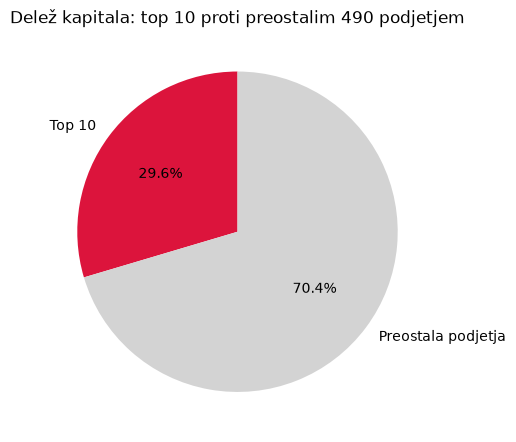

In [ ]:
top_n=10 

df_urejen = df.sort_values("Market_Cap_USD", ascending=False).reset_index(drop=True)

skupni_kapital = df_urejen["Market_Cap_USD"].sum() 
kapital_top = df_urejen.head(top_n)["Market_Cap_USD"].sum() 

delez_top = kapital_top / skupni_kapital * 100
delez_ostali = 100 - delez_top
kapital_ostali = skupni_kapital - kapital_top

plt.figure(figsize=(5, 5))
plt.pie(
        [kapital_top, kapital_ostali], # [kapital_top, kapital_ostali]: Dva zneska, ki določata velikosti obeh kosov torte.
        labels=[f"Top {top_n}", "Preostala podjetja"],
        autopct="%1.1f%%", # autopct="%1.1f%%": Samodejno izračuna in napiše odstotke neposredno na kosa torte in zaokroži na eno decimalno mesto
        colors=["crimson", "lightgray"],
        startangle=90, # zasuče tortni diagram za 90 stopinj, da prvi rez poteka navpično navzgor
    )
plt.title(f"Delež kapitala: top {top_n} proti preostalim {len(df_urejen) - top_n} podjetjem")
plt.tight_layout()
plt.show()



Iz tortnega diagrama lahko razberemo naslednje ugotovitve:

**Izjemna moč največjih desetih:** Prvih 10 podjetij obvladuje ogromen del celotnega trga. Kljub temu da gre le za 2 % vseh opazovanih podjetij, imajo v rokah zelo velik odstotek celotnega kapitala.

**Velika razlika do preostalih podjetij:** Preostalih 490 podjetij skupaj deli preostanek trga, kar pomeni, da je povprečna vrednost posameznega podjetja zunaj prve deseterice bistveno manjša.

**Tržna nesorazmernost:** Podatki potrjujejo, da svetovni trg obvladuje peščica tehnoloških in industrijskih gigantov, ki po svoji vrednosti močno odskočijo od vseh ostalih tekmencev.

## 3. PARETOVO PRAVILO (80/20)

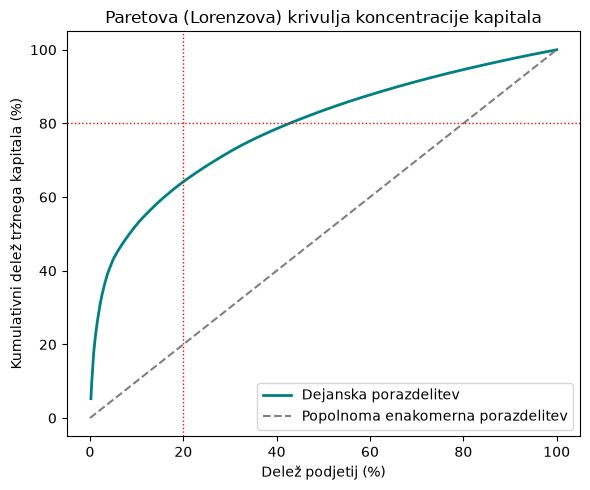

In [ ]:
df_urejen = df.sort_values("Market_Cap_USD", ascending=False).reset_index(drop=True)
n = len(df_urejen)
skupni_kapital = df_urejen["Market_Cap_USD"].sum()
kumulativni_kapital = df_urejen["Market_Cap_USD"].cumsum() 
kumulativni_delez = kumulativni_kapital / skupni_kapital * 100
delez_podjetij = (np.arange(1, n + 1) / n) * 100 
stevilo_za_80 = int(np.searchsorted(kumulativni_delez.values, 80) + 1) 
delez_podjetij_za_80 = stevilo_za_80 / n * 100
n_20_odstotkov = max(1, int(round(n * 0.2))) 
delez_kapitala_pri_20 = kumulativni_delez.iloc[n_20_odstotkov - 1]

plt.figure(figsize=(6, 5))
plt.plot(delez_podjetij, kumulativni_delez, color="teal", linewidth=2, label="Dejanska porazdelitev")
plt.plot([0, 100], [0, 100], color="gray", linestyle="--", label="Popolnoma enakomerna porazdelitev")
plt.axhline(80, color="red", linestyle=":", linewidth=1)
plt.axvline(20, color="red", linestyle=":", linewidth=1)
plt.xlabel("Delež podjetij (%)")
plt.ylabel("Kumulativni delež tržnega kapitala (%)")
plt.title("Paretova (Lorenzova) krivulja koncentracije kapitala")
plt.legend()
plt.tight_layout()
plt.show()

Paretovo pravilo (ali pravilo 80/20) v ekonomiji pomeni, da je porazdelitev bogastva ali kapitala pogosto izjemno neenakomerna. V našem primeru to pomeni, da naj bi približno 20\% največjih podjetij obvladovalo kar 80\% celotnega tržnega kapitala.

Glavna črta na grafu (Lorenzova krivulja) prikazuje dejansko odstopanje od popolnoma enakomerne porazdelitve.
Če bi vsa podjetja imela enako vrednost, bi krivulja potekala po sivi diagonali. Ker pa je ukrivljena močno navzgor, nam jasno pokaže, da majhen del podjetji upravlja z večino tržnega kapitala.

S presečiščem rdečih črt opazimo, da je koncentracija trga v praksi še bolj ekstremna, kot predvideva klasično pravilo 80/20. Do takšnih rezultatov prihaja predvsem zaradi sodobne strukture kapitalizma, kjer največja tehnološka in energetska podjetja (kot so Apple, Microsoft, NVIDIA ali Saudi Aramco) dosegajo vrednosti v bilijonih dolarjev in s tem obvladujejo večino celotne vrednosti na trgu, medtem ko stotine manjših podjetij skupaj prispevajo le skromen preostanek.

##  4. KORELACIJA IN REGRESIJA - velikost podjetja vs. dnevno nihanje

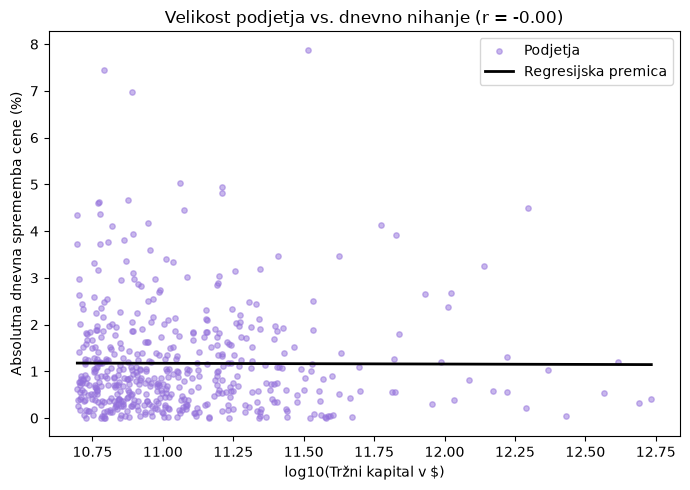

In [ ]:
df = df.copy()
df["log_Market_Cap"] = np.log10(df["Market_Cap_USD"]) # Pandas ustvari nov stolpec |  NumPy izvede logaritem. np.log10(...): Ustvari nov stolpec z logaritmirano vrednostjo tržnega kapitala (X-os)
# zanima nas VELIKOST nihanja (volatilnost), zato vzamemo absolutno vrednost spremembe
df["Absolutna_Sprememba"] = df["Sprememba_Odstotek"].abs()

x = df["log_Market_Cap"]
y = df["Absolutna_Sprememba"]

# Pearsonov korelacijski koeficient
r, p_vrednost = stats.pearsonr(x, y)
# r: Pearsonov korelacijski koeficient (številka med -1 in +1, ki pove smer in moč povezave).
# p_vrednost: Statistična verjetnost (pove, ali je rezultat zanesljiv ali zgolj naključen)

# linearna regresija (y = k*x + n)
rezultat_regresije = stats.linregress(x, y) # linregress iz oblaka točk na grafu poišče najbolj ravno črto ki jo lahko potegnemo med podatki
k = rezultat_regresije.slope # slope je naklon
n = rezultat_regresije.intercept 

plt.figure(figsize=(7, 5))
plt.scatter(x, y, alpha=0.5, s=15, color="mediumpurple", label="Podjetja")
x_linija = np.linspace(x.min(), x.max(), 100)
plt.plot(x_linija, k * x_linija + n, color="black", linewidth=2, label="Regresijska premica")
plt.xlabel("log10(Tržni kapital v $)")
plt.ylabel("Absolutna dnevna sprememba cene (%)")
plt.title(f"Velikost podjetja vs. dnevno nihanje (r = {r:.2f})")
plt.legend()
plt.tight_layout()
plt.show()

Graf prikazuje povezavo med velikostjo podjetja (njegovo tržno vrednostjo na X-osi) in njegovo dnevno nihajnostjo oziroma spremembo cene delnice na borzi (na Y-osi).

Črna regresijska premica je skoraj popolnoma ravna, vrednost korelacije pa je praktično enaka nič ($r \approx 0$). To nam jasno pove, da med velikostjo podjetja in tem, za koliko odstotkov se na posamezen dan spremeni cena njegove delnice, ni nobene povezave.

Do takšnih rezultatov prihaja zato, ker na kratkoročna dnevna nihanja cen na borzi vplivajo povsem drugi dejavniki. Tudi največji globalni giganti (kot so Apple, Microsoft ali Nvidia) so na dnevni ravni enako izpostavljeni splošnemu razpoloženju na trgu, svežim gospodarskim novicam, geopolitičnim dogodkom ali objavam četrtletnih poslovnih rezultatov kot manjša podjetja. Tržna velikost podjetja torej prinaša stabilnost na dolgi rok, ne varuje pa delnice pred običajnimi dnevnimi vzponi in padci na borzi.

##  5. ISKANJE OSAMELCEV (Z-VRENDOST)

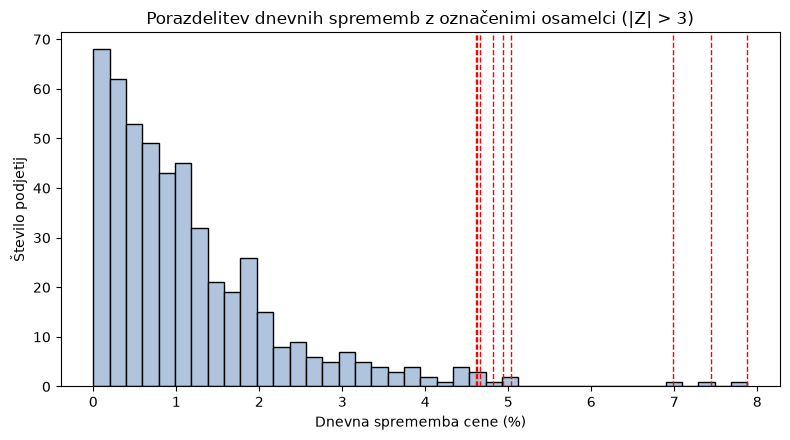

In [ ]:
prag=3
df = df.copy()
povprecje = df["Sprememba_Odstotek"].mean()
std_odklon = df["Sprememba_Odstotek"].std()

    # Z-score pove, koliko standardnih odklonov je vrednost oddaljena od povprečja
df["Z_score"] = (df["Sprememba_Odstotek"] - povprecje) / std_odklon

osamelci = df[df["Z_score"].abs() > prag].sort_values("Z_score", key=lambda s: s.abs(), ascending=False)
    # [df["Z_score"].abs() > prag] preveri pogoj za vsako vrstico.
    
plt.figure(figsize=(8, 4.5))
plt.hist(df["Sprememba_Odstotek"], bins=40, color="lightsteelblue", edgecolor="black")
for _, vrstica in osamelci.iterrows(): # .z iterrows vrne indeks vrstcie in vsebino vrstice
    plt.axvline(vrstica["Sprememba_Odstotek"], color="red", linestyle="--", linewidth=1)
plt.xlabel("Dnevna sprememba cene (%)")
plt.ylabel("Število podjetij")
plt.title(f"Porazdelitev dnevnih sprememb z označenimi osamelci (|Z| > {prag})")
plt.tight_layout()
plt.show()

Graf prikazuje porazdelitev dnevnih sprememb cen delnic za vsa opazovana podjetja, pri čemer so z rdečimi črtami označeni tako imenovani osamelci – podjetja, katerih dnevni skok ali padec močno odstopa od povprečja celotnega trga (Z-vrednost je večja od 3).

Večina podjetij se nahaja v osrednjem delu histograma, kar pomeni, da so njihova običajna dnevna nihanja razmeroma majhna in se gibljejo blizu ničle. Rdeče črte na obrobju pa prikazujejo posamezna podjetja z izjemno visokimi pozitivnimi ali negativnimi spremembami.

Do takšnih ekstremnih odstopanj v praksi prihaja zaradi izrednih dogodkov, ki so specifični za posamezno podjetje ali njegovo panogo. Sem spadajo npr. nepričakovano dobre ali slabe objave četrtletnih poslovnih rezultatov, prevzemi in združitve podjetji, pomembne spremembe v vodstvu ali pa nenadni geopolitični in regulatorni šoki. Ti rezultati nam sporočajo, da čeprav je celoten trg v povprečju stabilen, na posamezne delnice občasno vplivajo specifične novice, ki povzročijo kratkoročne "izredne dogodke" na borzi.